In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [2]:
data = pd.read_csv("data/train_FD001.txt", sep=" ", header=None)
data = data.dropna(axis=1)

# Column naming
columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3']
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
data.columns = columns + sensor_cols

data.head()

,engine_id,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
features = data[sensor_cols]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [4]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # slightly stricter (better)
    random_state=42
)

model.fit(features_scaled)

data['anomaly_score'] = model.decision_function(features_scaled)
data['anomaly'] = model.predict(features_scaled)

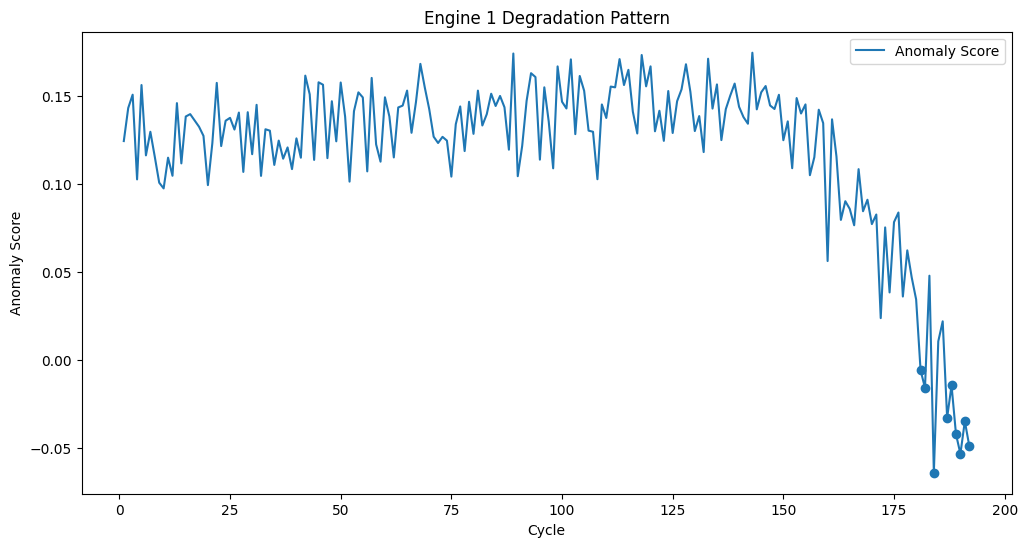

In [5]:
engine_id = 1
engine_data = data[data['engine_id'] == engine_id]

plt.figure(figsize=(12,6))

plt.plot(engine_data['cycle'], engine_data['anomaly_score'], label='Anomaly Score')

anomalies = engine_data[engine_data['anomaly'] == -1]
plt.scatter(anomalies['cycle'], anomalies['anomaly_score'])

plt.xlabel("Cycle")
plt.ylabel("Anomaly Score")
plt.title(f"Engine {engine_id} Degradation Pattern")
plt.legend()

plt.show()

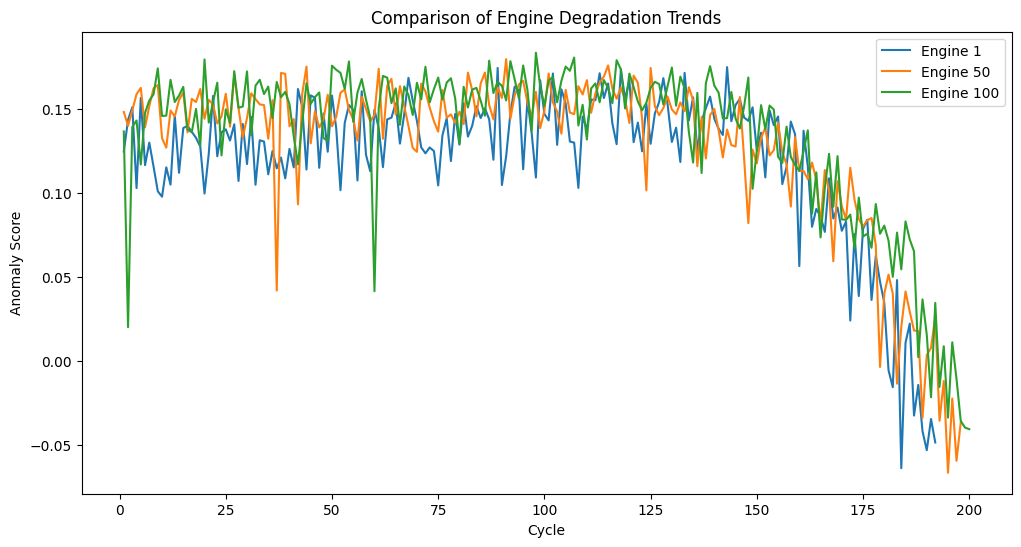

In [6]:
plt.figure(figsize=(12,6))

for eid in [1, 50, 100]:
    temp = data[data['engine_id'] == eid]
    plt.plot(temp['cycle'], temp['anomaly_score'], label=f'Engine {eid}')

plt.xlabel("Cycle")
plt.ylabel("Anomaly Score")
plt.title("Comparison of Engine Degradation Trends")
plt.legend()

plt.show()

In [7]:
# Calculate max cycle for each engine
max_cycle = data.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

# Merge with original data
data = data.merge(max_cycle, on='engine_id')

# Compute RUL
data['RUL'] = data['max_cycle'] - data['cycle']

data[['engine_id', 'cycle', 'RUL']].head()

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


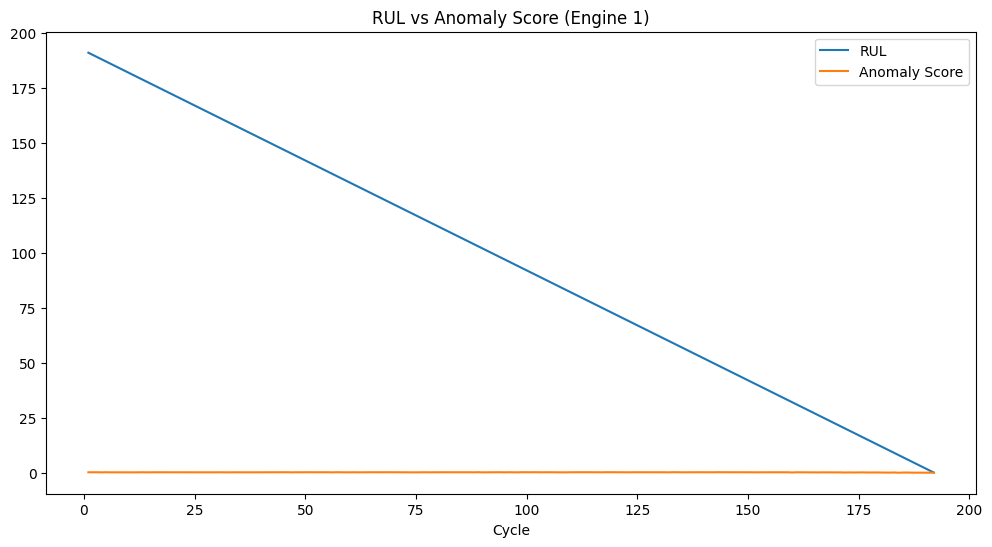

In [8]:
engine_id = 1
engine_data = data[data['engine_id'] == engine_id]

plt.figure(figsize=(12,6))

plt.plot(engine_data['cycle'], engine_data['RUL'], label='RUL')
plt.plot(engine_data['cycle'], engine_data['anomaly_score'], label='Anomaly Score')

plt.xlabel("Cycle")
plt.title(f"RUL vs Anomaly Score (Engine {engine_id})")
plt.legend()

plt.show()

In [9]:
correlation = data[['RUL', 'anomaly_score']].corr()
print(correlation)


                    RUL  anomaly_score
RUL            1.000000       0.358096
anomaly_score  0.358096       1.000000


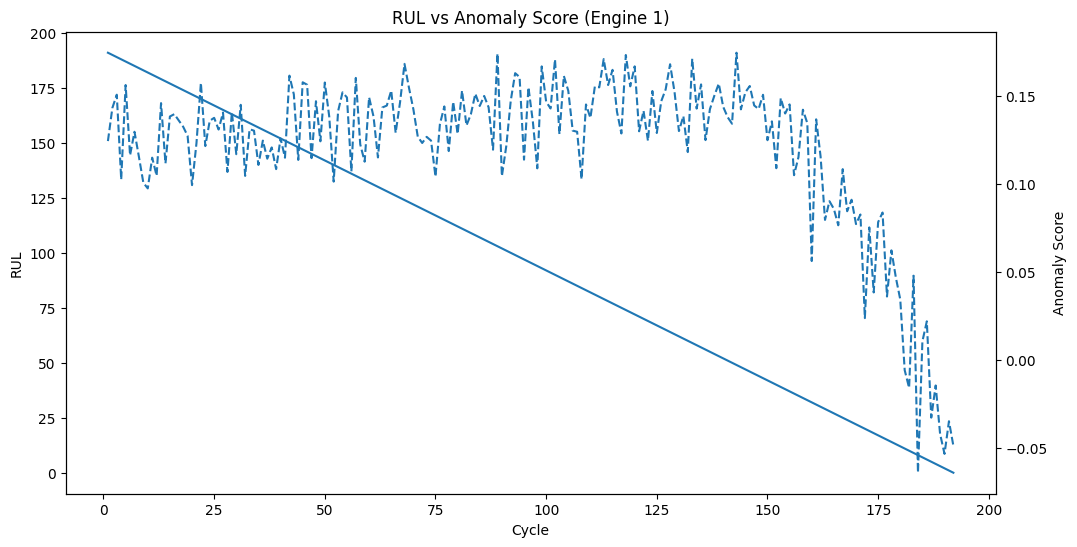

In [10]:
engine_id = 1
engine_data = data[data['engine_id'] == engine_id]

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Cycle")
ax1.set_ylabel("RUL")
ax1.plot(engine_data['cycle'], engine_data['RUL'], label='RUL')

ax2 = ax1.twinx()
ax2.set_ylabel("Anomaly Score")
ax2.plot(engine_data['cycle'], engine_data['anomaly_score'], linestyle='dashed', label='Anomaly Score')

plt.title(f"RUL vs Anomaly Score (Engine {engine_id})")

plt.show()